# Project 2 – Heart Disease Prediction

## 🎯 Project Goal

In this project, our goal is to predict **whether a patient has heart disease or not** based on their medical information.

**Target Variable:**
- `0` → No Heart Disease
- `1` → Heart Disease

So, this is a **Classification Problem**.

---

## 🔄 How is it different from Project 1?

| Project 1 | Project 2 |
|-----------|-----------|
| Predict Insurance Charges | Predict Heart Disease |
| Numerical Output | Categorical Output |
| Regression | Classification |

---

## 🧠 Workflow

The overall pipeline remains almost the same:

- Load Dataset
- EDA
- Data Cleaning
- Data Preprocessing
- Feature Selection
- Model Training
- Model Evaluation
- Prediction

Only the **model** and **evaluation metrics** will change because the target is **categorical**, not numerical.

---

## 💡 Thinking

Before writing any ML model, always identify the target variable.

- **Numerical Target → Regression**
- **Categorical Target → Classification**

This is the first decision every ML Engineer makes before starting a project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


# Basic EDA

In [2]:
df = pd.read_csv('heart.csv',encoding='utf-8')
print('Shape of data: ',df.shape)
print(df)

Shape of data:  (918, 12)
     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [7]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
print(df.duplicated().sum())

0


# Visual EDA & Data Cleaning

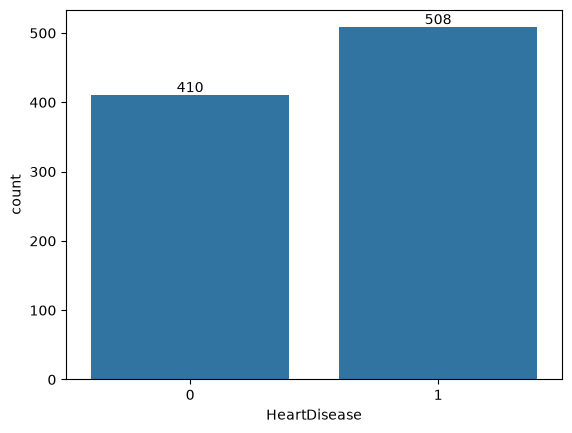

In [9]:
ax = sns.countplot(x=df['HeartDisease'])
ax.bar_label(ax.containers[0])
plt.show()

Countplot of HeartDisease

Why?

To check whether the target classes are balanced or not.

If one class has significantly more samples than the other, the model can become biased toward the majority class.

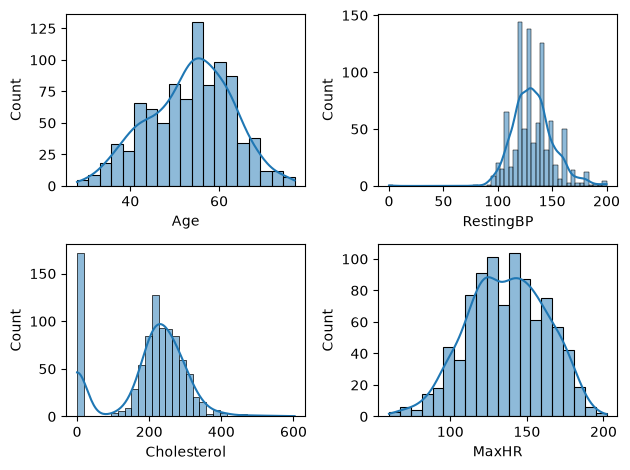

In [10]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)
    plt.tight_layout()

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

### Observations from graphs:
- 1st and 4th graph is normally distributed
- 2nd graph have a invalid value because resting BP can't be zero
- 3rd graph have many values with 0 may be that was because empty values (null) are filled by 0 that may be a possibility 

In [11]:
mean_cholesterol = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
print(mean_cholesterol)

244.6353887399464


<Axes: xlabel='Cholesterol', ylabel='Count'>

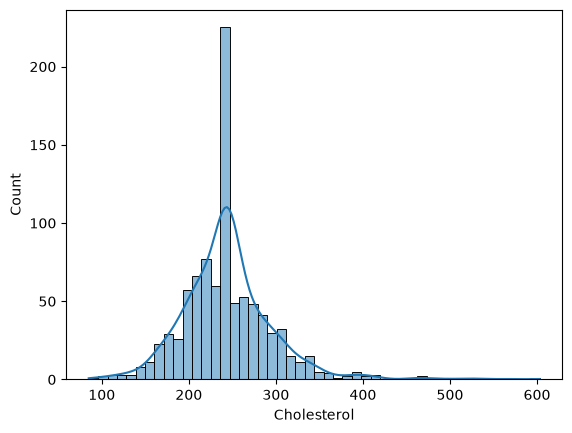

In [12]:
df['Cholesterol'] = df['Cholesterol'].replace(0,mean_cholesterol)
df['Cholesterol'] = df['Cholesterol'].round(2)
sns.histplot(df['Cholesterol'],kde=True)

### A person can have a cholesterol of 600 so that last point is ok 

<Axes: xlabel='RestingBP', ylabel='Count'>

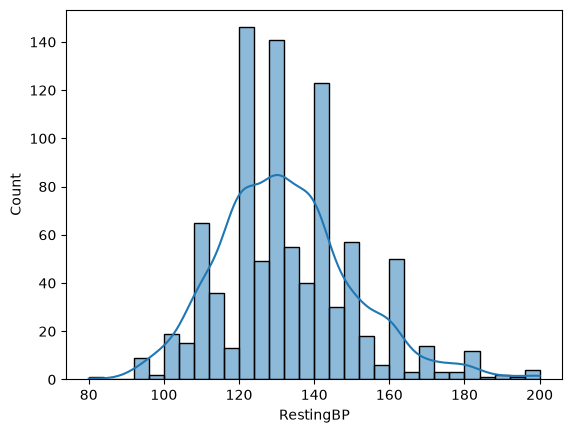

In [13]:
mean_RestingBP = df.loc[df['RestingBP'] !=0 , 'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,mean_RestingBP)
df['RestingBP'] = df['RestingBP'].round(2)
sns.histplot(df['RestingBP'],kde=True)

sns.countplot(x=df['Sex'],hue=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

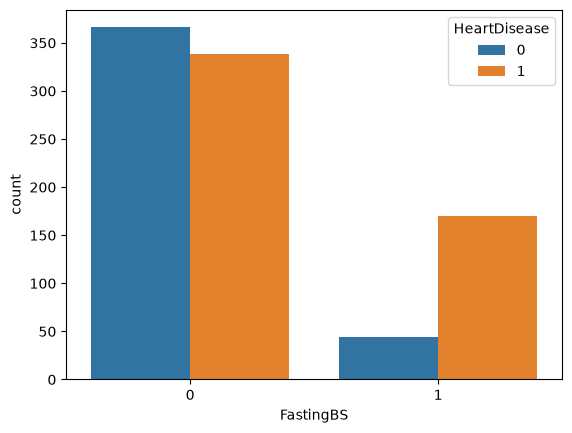

In [14]:
sns.countplot(x=df['FastingBS'],hue=df['HeartDisease'])

Countplot of Sex with hue='HeartDisease'

Why?

To compare the distribution of Heart Disease separately for males and females.

Instead of just knowing how many males/females exist, we want to know which gender is more affected.

<Axes: xlabel='ChestPainType', ylabel='count'>

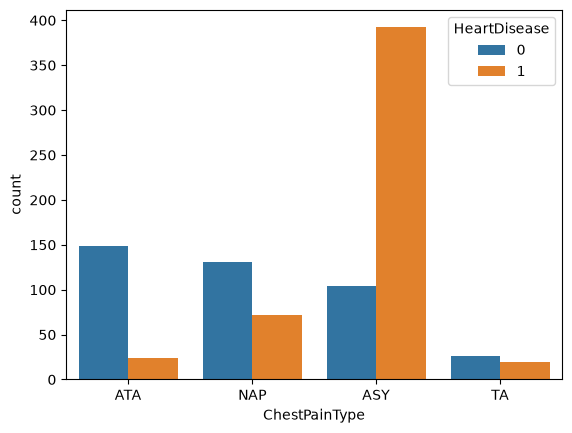

In [15]:
sns.countplot(x=df['ChestPainType'],hue=df['HeartDisease'])

Countplot of ChestPainType with hue='HeartDisease'

Why?

To check whether different chest pain types have different heart disease frequencies.

If one category contains significantly more heart disease cases, it can become an important predictive feature.

<Axes: xlabel='RestingECG', ylabel='count'>

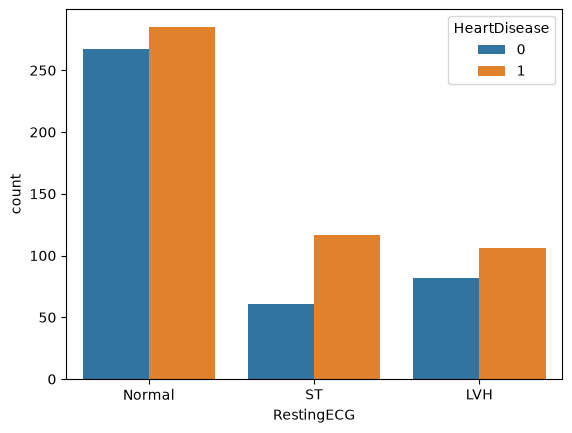

In [16]:
sns.countplot(x=df['RestingECG'],hue=df['HeartDisease'])

Countplot of RestingECG with hue='HeartDisease'

Why?

To check whether different Resting ECG results are associated with the presence of heart disease.

hue='HeartDisease' add karne se hum sirf ECG categories ki count nahi dekhte, balki har ECG category me kitne patients ko heart disease hai aur kitno ko nahi, ye compare kar paate hain.

<Axes: xlabel='ST_Slope', ylabel='count'>

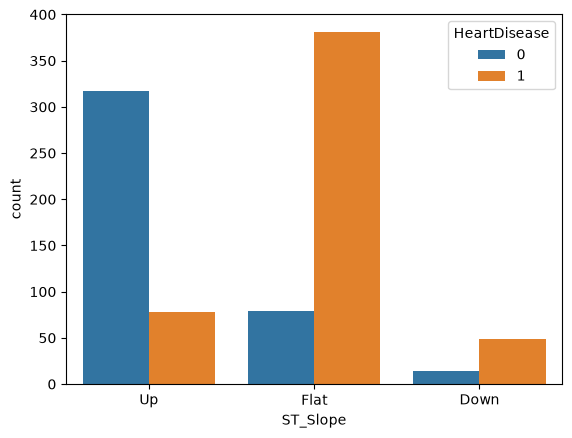

In [17]:
sns.countplot(x=df['ST_Slope'],hue=df['HeartDisease'])

Countplot of ST_Slope with hue='HeartDisease'

Why?

To compare heart disease occurrence across different ECG slope categories.

A category showing many positive cases may carry strong predictive information.

<Axes: xlabel='ExerciseAngina', ylabel='count'>

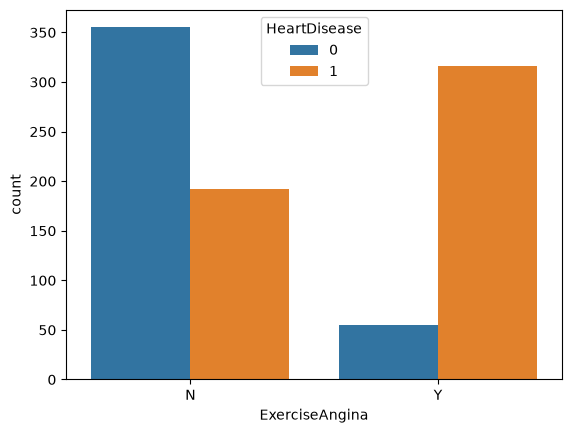

In [18]:
sns.countplot(x=df['ExerciseAngina'],hue=df['HeartDisease'])

Countplot of ExerciseAngina with hue='HeartDisease'

Why?

To see whether patients experiencing exercise-induced angina are more likely to have heart disease.

This helps us understand if this symptom is strongly associated with the target.

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

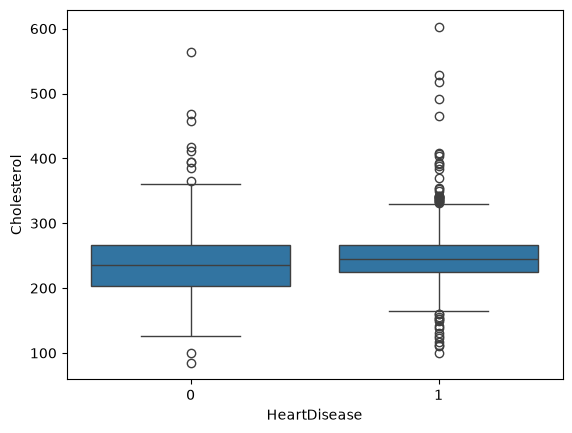

In [19]:
sns.boxplot(x = 'HeartDisease', y='Cholesterol',data=df)

Why?

To compare the cholesterol distribution between patients with and without heart disease.

We want to check:

Is the median cholesterol different?
Are there many outliers?
Is cholesterol a potentially useful feature?

💡 Interpretation

Heart disease patients have a slightly higher median cholesterol.
Both groups contain several outliers.
Cholesterol alone cannot separate the two classes, but it may still help the model.

<Axes: xlabel='HeartDisease', ylabel='Age'>

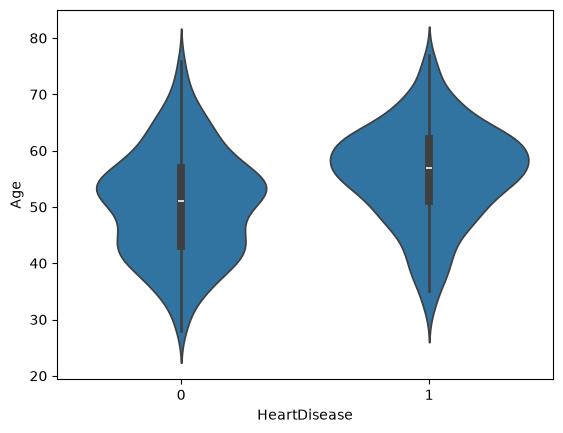

In [20]:
sns.violinplot(x='HeartDisease',y='Age',data=df)

Why?

To visualize the complete age distribution for both classes.

Unlike a boxplot, it also shows where most patients are concentrated (density).

💡 Interpretation

Heart disease cases are mostly concentrated in higher age groups.

Non-heart disease cases are relatively younger.

This indicates Age is an important predictive feature.

<Axes: >

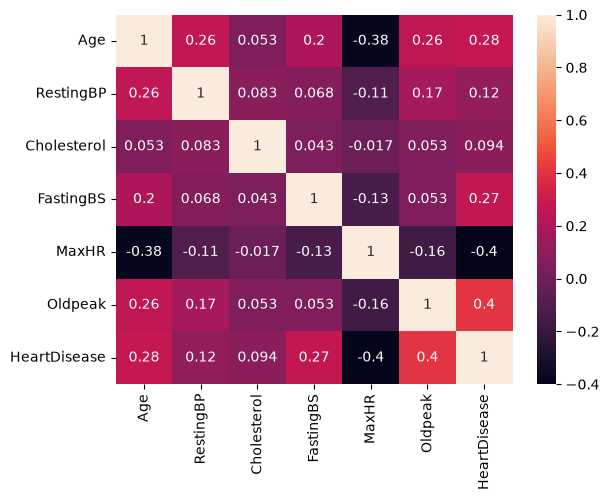

In [21]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

Why?

To check how numerical features are related to each other and the target (HeartDisease).

Ye graph hume batata hai:

Kaunsa feature target se strongly related hai.
Kya do features ek hi information de rahe hain (Multicollinearity).

💡 Interpretation

Oldpeak (0.40) → Positive correlation with HeartDisease.

→ Jitna Oldpeak badhta hai, HeartDisease ki possibility bhi badhti dikhti hai.

MaxHR (-0.40) → Negative correlation.

→ Higher Maximum Heart Rate generally means lower chance of Heart Disease.

Age (0.28) & FastingBS (0.27) → Weak to moderate positive relation.

Cholesterol (0.094) → Almost no linear relationship with HeartDisease.

# Feature Engineering

In [22]:
df['Cholesterol_category'] = pd.cut(
    df['Cholesterol'],
    bins = [0,199,239,float("inf")],
    labels=["Normal","Borderline","High"]
)

df["Age_group"] = pd.cut(
    df['Age'],
    bins = [18,35,55,float("inf")],
    labels = ['Young','Middle_Age','Senior']
)

df["High_risk"] = (
    (df["Age"] >= 55) &
    (df["ExerciseAngina"] == "Y") &
    (df["Cholesterol"] >= 240)
)

In [23]:
df_encode = pd.get_dummies(df,drop_first=True)
df_encoded = df_encode.astype(int)
df_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,High_risk,Sex_M,ChestPainType_ATA,...,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,Cholesterol_category_Borderline,Cholesterol_category_High,Age_group_Middle_Age,Age_group_Senior
0,40,140,289,0,172,0,0,0,1,1,...,0,1,0,0,0,1,0,1,1,0
1,49,160,180,0,156,1,1,0,0,0,...,0,1,0,0,1,0,0,0,1,0
2,37,130,283,0,98,0,0,0,1,1,...,0,0,1,0,0,1,0,1,1,0
3,48,138,214,0,108,1,1,0,0,0,...,0,1,0,1,1,0,1,0,1,0
4,54,150,195,0,122,0,0,0,1,0,...,0,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,0,1,0,...,1,1,0,0,1,0,0,1,1,0
914,68,144,193,1,141,3,1,0,1,0,...,0,1,0,0,1,0,0,0,0,1
915,57,130,131,0,115,1,1,0,1,0,...,0,1,0,1,1,0,0,0,0,1
916,57,130,236,0,174,0,1,0,0,1,...,0,0,0,0,1,0,1,0,0,1


# 🧩 Code Explanation

## 🔹 `pd.get_dummies(df)`

Converts all **categorical columns** into **One-Hot Encoded** columns.

### 📌 Example

**Before**

| Sex |
|:---:|
| M |
| F |

⬇️

**After**

| Sex_M |
|:-----:|
| 1 |
| 0 |

> Here, each category is converted into a separate binary (0/1) column.

---

## 🔹 `drop_first=True`

Removes the **first category** of every categorical feature.

### 🤔 Why?

It helps avoid the **Dummy Variable Trap**, where multiple dummy columns contain redundant information.

### 📌 Example

Instead of creating:

| Sex_F | Sex_M |
|:-----:|:-----:|
|   1   |   0   |
|   0   |   1   |

We keep only:

| Sex_M |
|:-----:|
|   0   |
|   1   |

### ✅ Interpretation

- `0` → Female
- `1` → Male

Even after removing one column, the model can still identify both categories.

---

## 🔹 `astype(int)`

By default, `pd.get_dummies()` returns **Boolean (`True` / `False`)** values.

Using:

```python
.astype(int)
```

converts them into **integer (`0` / `1`)** values.

### 📌 Example

**Before**

| Sex_M |
|:-----:|
| True  |
| False |

⬇️

**After**

| Sex_M |
|:-----:|
|   1   |
|   0   |

✨ This makes the dataset cleaner, more readable, and compatible with most Machine Learning algorithms.

In [24]:
from sklearn.preprocessing import StandardScaler
numerical_columns = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler = StandardScaler()
df_encoded[numerical_columns] = scaler.fit_transform(df_encoded[numerical_columns])
df_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,High_risk,Sex_M,ChestPainType_ATA,...,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,Cholesterol_category_Borderline,Cholesterol_category_High,Age_group_Middle_Age,Age_group_Senior
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,0,1,1,...,0,1,0,0,0,1,0,1,1,0
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,0,...,0,1,0,0,1,0,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,0,1,1,...,0,0,1,0,0,1,0,1,1,0
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,...,0,1,0,1,1,0,1,0,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,0,1,0,...,0,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253622,0.365619,0,-0.188999,0.282891,1,0,1,0,...,1,1,0,0,1,0,0,1,1,0
914,1.536902,0.637353,-0.966725,1,0.164684,2.303858,1,0,1,0,...,0,1,0,0,1,0,0,0,0,1
915,0.370100,-0.141284,-2.130180,0,-0.857069,0.282891,1,0,1,0,...,0,1,0,1,1,0,0,0,0,1
916,0.370100,-0.141284,-0.159813,0,1.461525,-0.727592,1,0,0,1,...,0,0,0,0,1,0,1,0,0,1


# ⚙️ Feature Scaling (Standardization)

## 🎯 Why do we need Scaling?

Machine Learning algorithms don't understand the **meaning** of numbers; they only see their **magnitude**.

Example:

| Feature | Range |
|---------|------:|
| Age | 28 - 77 |
| Cholesterol | 100 - 600 |
| Oldpeak | 0 - 6 |

Notice that **Cholesterol values are much larger than Age**.

If we directly train the model, algorithms that depend on **distance or optimization** may give **more importance to Cholesterol**, simply because its values are larger—not because it's actually more important.

Scaling solves this problem by bringing all numerical features to a **similar scale**.

---

## 🧠 Before vs After Scaling

### Before Scaling

```text
Age         = 40
Cholesterol = 289
Oldpeak     = 0.0
```

Each feature has a completely different range.

---

### After Scaling

```text
Age         = -1.43
Cholesterol = 0.82
Oldpeak     = -0.72
```

Now all features are centered around **0** and have a similar spread.

👉 Notice that **the values changed, but the information did not.**

The patient is still the same; only the **representation** of the data has changed.

---

## 🧠 Code Explanation

### `StandardScaler()`

Creates a scaler object that performs **Standardization**.

---

### `numerical_columns`

List of only those columns that need scaling.

We **don't scale binary columns (0/1)** because they're already on a small, consistent scale.

---

### `fit_transform()`

This performs **two steps together**:

### `fit()`

Learns the dataset statistics:

- Mean (Average)
- Standard Deviation (Spread)

Example:

```text
Age

Mean = 53
Std  = 9
```

---

### `transform()`

Uses those learned values to convert every value into the new standardized scale.

Formula (just for understanding):

```text
Scaled Value = (Value - Mean) / Standard Deviation
```

You don't need to memorize it—just remember:

- Subtract Mean → Center around 0
- Divide by Std → Bring values to a similar scale

---

## 🤔 Why are some values negative?

Suppose:

```text
Average Age = 53
```

A patient with:

```text
Age = 40
```

is **below the average**, so after scaling it becomes negative.

Similarly,

```text
Age = 65
```

is above average, so it becomes positive.

Negative doesn't mean "bad"—it simply means **below the dataset's average**.

---

## 🎯 Why didn't we scale every column?

We scaled only continuous numerical features:

- Age
- RestingBP
- Cholesterol
- MaxHR
- Oldpeak

We **didn't scale**:

- HeartDisease
- Sex_M
- ChestPainType_ATA
- RestingECG_...
- All other 0/1 columns

because they are already binary features. Scaling them usually adds no meaningful benefit.

---

## 💼 Industry Perspective

Algorithms like:

- KNN
- SVM
- Logistic Regression
- Neural Networks

perform better when features are on a similar scale.

Algorithms like:

- Decision Tree
- Random Forest
- XGBoost

generally **do not require scaling** because they don't rely on distance calculations.

# Feature Selection

In [26]:
from scipy.stats import pearsonr

numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

correlations = {}

for feature in numerical_features:
    corr, p_value = pearsonr(df_encoded[feature], df_encoded["HeartDisease"])
    correlations[feature] = corr

correlation_df = pd.DataFrame(
    correlations.items(),
    columns=["Feature", "Correlation"]
)

correlation_df.sort_values(
    by="Correlation",
    ascending=False
)

,Feature,Correlation
4,Oldpeak,0.392385
0,Age,0.282039
1,RestingBP,0.117909
2,Cholesterol,0.092586
3,MaxHR,-0.400421


In [27]:
from scipy.stats import chi2_contingency

categorical_features = [
    "Sex_M",
    "ChestPainType_ATA",
    "ChestPainType_NAP",
    "ChestPainType_TA",
    "RestingECG_Normal",
    "RestingECG_ST",
    "ExerciseAngina_Y",
    "ST_Slope_Flat",
    "ST_Slope_Up"
]

alpha = 0.05

chi_results = {}

for feature in categorical_features:

    table = pd.crosstab(
        df_encoded[feature],
        df_encoded["HeartDisease"]
    )

    chi2, p, _, _ = chi2_contingency(table)

    chi_results[feature] = p

chi_df = pd.DataFrame(
    chi_results.items(),
    columns=["Feature", "P-value"]
)

chi_df.sort_values(by="P-value")

,Feature,P-value
8,ST_Slope_Up,1.028493e-78
7,ST_Slope_Flat,8.906496e-63
6,ExerciseAngina_Y,2.907808e-50
1,ChestPainType_ATA,1.152597e-33
0,Sex_M,4.597617e-20
2,ChestPainType_NAP,1.859758e-10
5,RestingECG_ST,2.507290e-03
4,RestingECG_Normal,6.790624e-03
3,ChestPainType_TA,1.315768e-01


In [31]:
selected_features = [
    "Age",
    "MaxHR",
    "Oldpeak",
    "ExerciseAngina_Y",
    "ST_Slope_Up",
    "ChestPainType_ATA",
    "HeartDisease"
]

final_df = df_encoded[selected_features]

final_df

,Age,MaxHR,Oldpeak,ExerciseAngina_Y,ST_Slope_Up,ChestPainType_ATA,HeartDisease
0,-1.433140,1.382928,-0.727592,0,1,1,0
1,-0.478484,0.754157,0.282891,0,0,0,1
2,-1.751359,-1.525138,-0.727592,0,1,1,0
3,-0.584556,-1.132156,0.282891,1,0,0,1
4,0.051881,-0.581981,-0.727592,0,1,0,0
...,...,...,...,...,...,...,...
913,-0.902775,-0.188999,0.282891,0,0,0,1
914,1.536902,0.164684,2.303858,0,0,0,1
915,0.370100,-0.857069,0.282891,1,0,0,1
916,0.370100,1.461525,-0.727592,0,0,1,1
